<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB


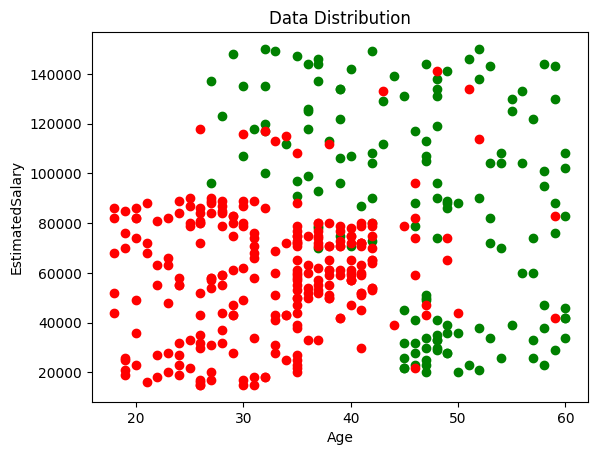

Training Accuracy: 88.125
Testing Accuracy: 82.5
Prediction: [1]


C:\Users\rs889\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [1]:
# 1. Classify data with KNN algorithm.

# Implement the algorithm with the help of the 'mobile.csv' dataset. Visualize purchased and not_purchased data distribution based on age and estimated salary using a scatter plot. Apply MinMaxScaler to the dataset. Predict if the customer will purchase a mobile or not.

# 2. Apply suitable Regression.

# Read computer.csv dataset. Find no. of columns and rows with given dataset. Which regression model fit with given dataset? Build suitable regression model with the data and fetch intercept and coefficient. Visualize Models using pyplot. Compute the Coefficient of Determination to find accuracy.


import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
# 1. KNN Algorithm
# Load the dataset
df = pd.read_csv('../ML Practicals/mobile.csv')

df.head()

df.info()

purchased_data = df[df["Purchased"]==1]
not_purchased_data = df[df["Purchased"]==0]

# Visualize the data distribution

plt.scatter(purchased_data['Age'], purchased_data['EstimatedSalary'], c='green', label='Purchased')
plt.scatter(not_purchased_data['Age'], not_purchased_data['EstimatedSalary'], c='red', label='Not Purchased')
plt.xlabel('Age')
plt.ylabel('EstimatedSalary')
plt.title('Data Distribution')
plt.show()

# Apply MinMaxScaler
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(df[['Age', 'EstimatedSalary']])
# Prepare features and target variable
X = df[['Age', 'EstimatedSalary']]
y = df['Purchased']
# Train KNN model

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=5)

model.fit(X_train, y_train)

print("Training Accuracy:", model.score(X_train, y_train)*100)

print("Testing Accuracy:", model.score(X_test, y_test)*100)

age = float(input("Enter normalized age: "))
salary = float(input("Enter normalized salary: "))

data = [[age, salary]]

prediction = model.predict(data)

print("Prediction:", prediction)
# 2. Regression
# Load the dataset




Rows: 14
Columns: 2


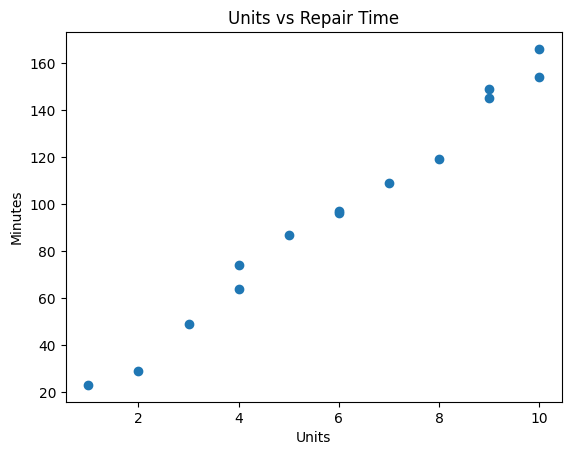

Intercept: 4.161654135338296
Coefficient: [15.50877193]


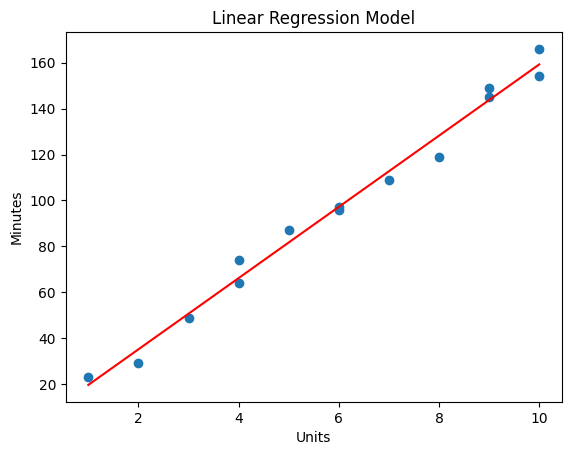

Coefficient of Determination (R²): 0.9874371980620736


In [2]:
computers = pd.read_csv('../ML Practicals/computers.csv')

computers.head()
print("Rows:", computers.shape[0])

print("Columns:", computers.shape[1])
plt.scatter(computers["Units"], computers["Minutes"])

plt.xlabel("Units")

plt.ylabel("Minutes")

plt.title("Units vs Repair Time")

plt.show()
X = computers[["Units"]]

y = computers["Minutes"]
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X, y)

print("Intercept:", model.intercept_)

print("Coefficient:", model.coef_)
plt.scatter(X, y)

plt.plot(X, model.predict(X), color='red')

plt.xlabel("Units")

plt.ylabel("Minutes")

plt.title("Linear Regression Model")

plt.show()
r2 = model.score(X, y)

print("Coefficient of Determination (R²):", r2)

In [ ]:
df = pd.read_csv('../ML Practicals/Iris.csv')

In [ ]:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [6]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [8]:
df.dtypes

Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species              str
dtype: object

All feature columns are numerical (float values).  
Therefore, **Gaussian Naive Bayes** is suitable for this dataset.

In [9]:
X = df.drop("Species", axis=1)
y = df["Species"]

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42)

In [11]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()

model.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [12]:
y_pred = model.predict(X_test)
print(y_pred)

['Iris-versicolor' 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-setosa' 'Iris-versicolor' 'Iris-virginica'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-versicolor'
 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-setosa' 'Iris-virginica'
 'Iris-virginica' 'Iris-virginica' 'Iris-virginica' 'Iris-virginica'
 'Iris-setosa' 'Iris-setosa']


In [14]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


In [16]:
df = df[df['Species'] != 'virginica']

In [24]:
v_nv_fn = lambda x: 0 if x == "Iris-versicolor" else 1
df["v_nv"] = df["Species"].apply(v_nv_fn)

In [27]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,species,v_nv
0,1,5.1,3.5,1.4,0.2,Iris-setosa,0,1
1,2,4.9,3.0,1.4,0.2,Iris-setosa,0,1
2,3,4.7,3.2,1.3,0.2,Iris-setosa,0,1
3,4,4.6,3.1,1.5,0.2,Iris-setosa,0,1
4,5,5.0,3.6,1.4,0.2,Iris-setosa,0,1


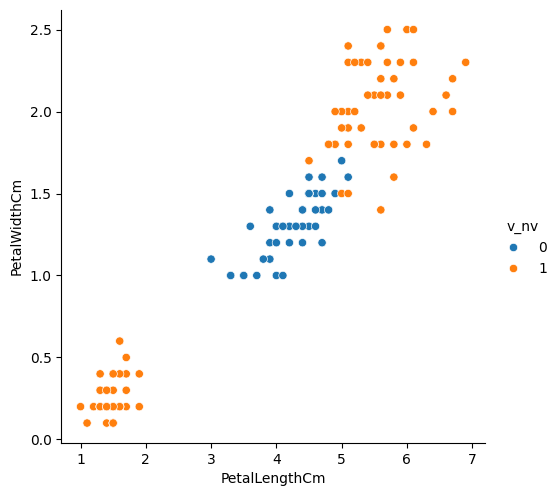

In [25]:
import seaborn as sns
sns.pairplot( df,x_vars="PetalLengthCm",y_vars="PetalWidthCm",hue="v_nv",height=5)

In [26]:
X = df[["PetalLengthCm","PetalWidthCm"]]
y = df["v_nv"]

In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
from sklearn.svm import SVC
model = SVC(kernel="linear")
model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [31]:
y_pred = model.predict(X_test)


In [32]:
print("Train Accuracy:", model.score(X_train, y_train))
print("Test Accuracy:", model.score(X_test, y_test))

Train Accuracy: 0.6583333333333333
Test Accuracy: 0.7


In [17]:
from sklearn.preprocessing import LabelEncoder
scaled = LabelEncoder()
df['species'] = scaled.fit_transform(df['Species'])

In [18]:
X = df.drop("Species", axis=1)
y = df["Species"]

In [19]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


In [1]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder

In [3]:
df = pd.read_csv('../ML Practicals/std_marks_data.csv')

In [4]:
df.columns

Index(['hours', 'age', 'internet', 'marks'], dtype='str')

In [5]:
df.head()

,hours,age,internet,marks
0,6.84,15,0,78.64
1,6.56,20,1,88.80
2,NaN,21,1,88.90
3,8.67,22,1,98.99
4,7.55,17,1,92.34


In [6]:
df.tail()

,hours,age,internet,marks
295,2.99,25,0,43.45
296,6.55,15,1,77.74
297,0.00,20,1,75.76
298,9.90,22,0,99.99
299,3.40,21,0,99.99


In [7]:
le = LabelEncoder()
df['marks'] = le.fit_transform(df['marks'])

In [9]:
X = df[['hours', 'age', 'internet']]
y = df['marks']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42)

read the std_marks_data.csv and handle missing values,define multiple predictor variables and a single target variable varaiable to train a Multiple Linear Regression model with an 80:20 split and evalute the final predictions using the mean sqaured error metric

simplify the iris dataset for binary classification. Implement a linear SVM and visualize the resulting decision boundary using mlxtend and support vectors. Report the final accuracy.
Question: What is a support vector in this algorithm?

In [11]:
df = pd.read_csv('../ML Practicals/Iris.csv')

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [13]:
df['Species'].unique()

<StringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str

In [14]:
v_nv_fn = lambda x:0 if x=="Iris-versicolor" else 1
df["v_nv"] = df["Species"].apply(v_nv_fn)
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,v_nv
0,1,5.1,3.5,1.4,0.2,Iris-setosa,1
1,2,4.9,3.0,1.4,0.2,Iris-setosa,1
2,3,4.7,3.2,1.3,0.2,Iris-setosa,1
3,4,4.6,3.1,1.5,0.2,Iris-setosa,1
4,5,5.0,3.6,1.4,0.2,Iris-setosa,1
...,...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica,1
146,147,6.3,2.5,5.0,1.9,Iris-virginica,1
147,148,6.5,3.0,5.2,2.0,Iris-virginica,1
148,149,6.2,3.4,5.4,2.3,Iris-virginica,1


In [15]:
import mlxtend

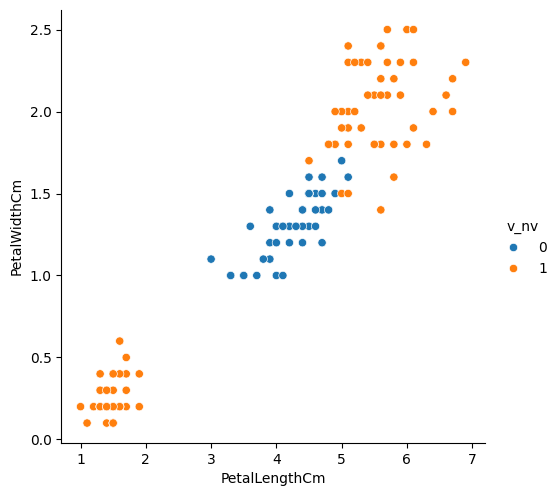

In [18]:
import seaborn as sns
sns. pairplot(df,x_vars = "PetalLengthCm",y_vars="PetalWidthCm",hue="v_nv", height=5)

In [19]:
from sklearn.svm import SVC
X = df[["PetalLengthCm", "PetalWidthCm"]]
y = df["v_nv"]
model = SVC()
model.fit(X, y)
model.score(X, y) * 100

95.33333333333334

C:\Users\rs889\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


Text(0.5, 1.0, 'Decision Boundary of SVM on iris data')

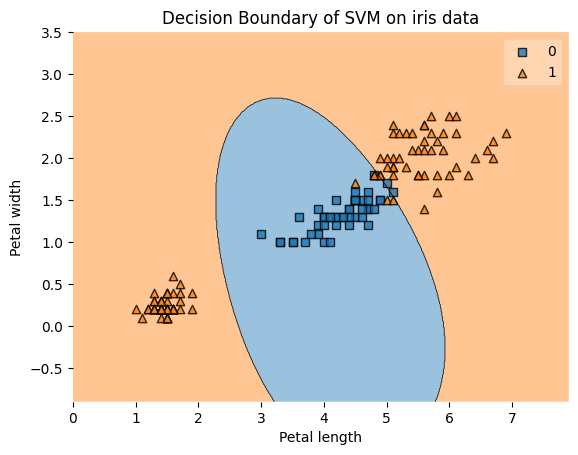

In [20]:
from mlxtend.plotting import plot_decision_regions
features = np.array(X)
target = np.array(y)
plot_decision_regions(features, target, clf=model)
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.title("Decision Boundary of SVM on iris data")

read house price dataset. Scale the features of the dataset using a standard scaler and implement lasso regression with a high alpha value to demonstrate feature selection, identifying which coefficients were reduced to exactly zero.
Question: How does lasso regression help us pick only the most important features?


In [1]:
import numpy as np

arr1 = np.random.uniform(5, 10, 10)
print("1D Array:\n", arr1)

1D Array:
 [9.66368798 9.88271865 8.84317786 7.88498172 7.15983343 7.54700088
 7.23105313 5.35824171 8.29144142 8.73509257]
